# Gaussian Process Regression (GPR) and Bayesian Optimization (BO)
We have talked a lot about managing your experimental budget (time, money, and other relevant resources) in this course. Today, we will talk about yet another strategy and tool for the same goal.

## Definitions

** Gaussian Process Regression (GPR)**: GPR is a way of modeling data that doesn't just give you a single "best guess" of a dependent variable based on one or more independent ones; it gives you a range of probability.

** Bayesian Optimization (BO)**: BO is a framework used to find the maximum or minimum of a "black-box" function (something that is expensive or slow to test).

** Their relationship**: BO uses GPR as its surrogate model (a digital twin of the experiment).

## Context

Imagine you're trying to find the best recipe for a material — maybe the ideal ratio of elements that maximizes strength — but each experiment is expensive and slow. You can't just try everything. Bayesian Optimization (BO) is a smart search strategy that learns from past experiments to decide where to look next, balancing exploring unknown regions vs. exploiting what's already working.
Gaussian Process Regression (GPR) is the engine inside BO. It's a probabilistic model that, given a handful of data points, predicts the output at untested locations and gives you a confidence interval (uncertainty estimate) for free. Think of it as drawing a distribution over possible functions that could fit your data — not just one "best fit" line, but a whole family of plausible ones.


## Part 1: Lab Handout
### 1.1. Gaussian Process Regression (GPR)
A similar concept to linear regression, you have some features, and you want to predict some properties. The difference here is that GPR can handle non-linear feature-property relationships.


We will be using GPR as implemented in sklearn. Let's dive in the example described in https://scikit-learn.org/stable/auto_examples/gaussian_process/plot_gpr_noisy_targets.html

Another useful link (GPR documentation): https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html#sklearn.gaussian_process.GaussianProcessRegressor 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import matplotlib.pyplot as plt

'We can call these values true values (for instance, they can be experimental data).'

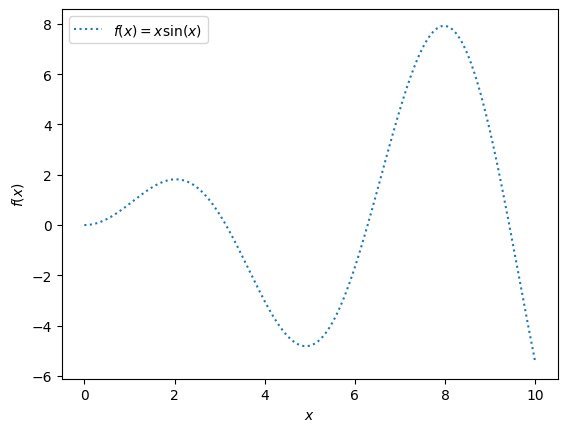

In [2]:
'''Data
Let's assume we have some materials properties f(x) that follows the relationship f(x) = x * sin(x).
We want to model this relationship using a Gaussian process. 
We will generate some data from this function and then fit a Gaussian process to it.'''
X = np.linspace(start=0, stop=10, num=1_000).reshape(-1, 1)
y = np.squeeze(X * np.sin(X))


plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")

'''We can call these values true values (for instance, they can be experimental data).'''

In [3]:
rng = np.random.RandomState(1)

'''Now, assume that we only have access to a few of these true values, and we do not know the true function that relates x and f(x).
 We will call the available data the training data. We will use this training data to fit a Gaussian process to the true function.'''
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

kernel = 1 * RBF(length_scale=1, length_scale_bounds=(1e-2, 1e2)) # note that you might need to optimize the kernel hyperparameters. Also, there are many kernels to choose from.
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gp.fit(X_train, y_train)
gp.kernel_


5.02**2 * RBF(length_scale=1.43)

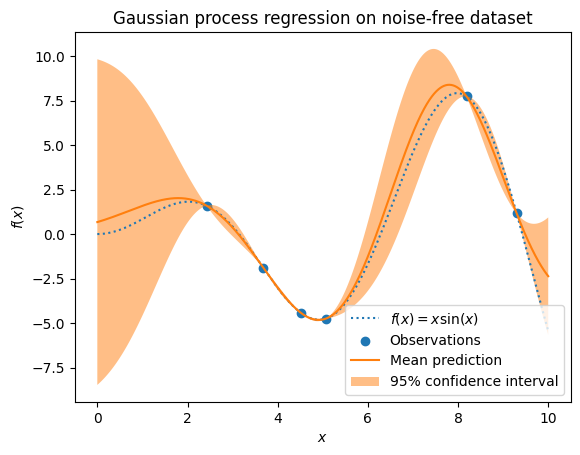

In [4]:
mean_prediction, std_prediction = gp.predict(X, return_std=True)

plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.scatter(X_train, y_train, label="Observations")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction, #Try to understand why 1.96
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

### 1.2. Active learning

Active learning is a machine learning approach that iteratively selects the most informative data points for model training. By actively choosing which data points to label, we can achieve better model performance with fewer labeled instances compared to passive learning. It is a valuable approach in scenarios where data labeling is resource-intensive.

In the plot above, we can see that the model is very uncertain below x=2. One way to decrease uncertainty and increase predictive power is by aquiring new points in that region. Let's acquire the point that has the highest uncertainty.

**NOTE:** The file *Basics of Bayesian Optimization.ipynb* (uploaded in Announcements) covers more examples of active learning techniques

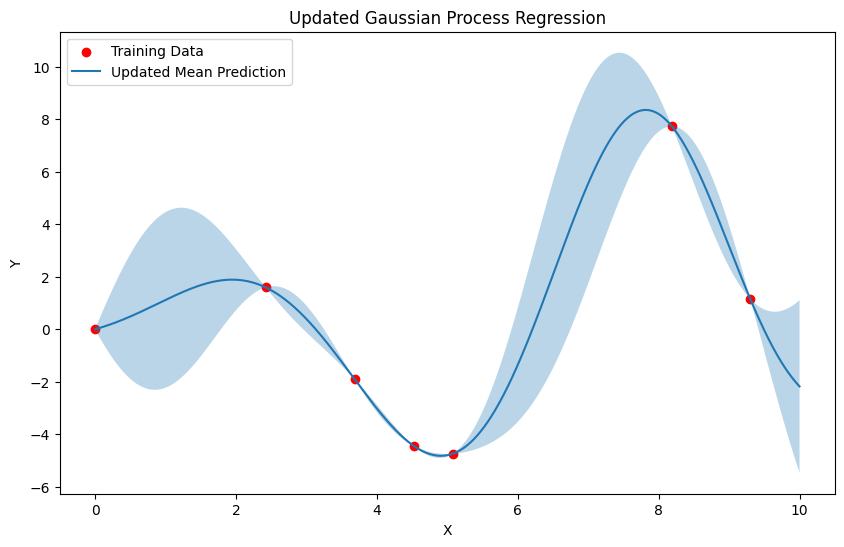

In [5]:
def uncertainty_sampling(model, pool): #our acquisition function
    y_pool_mean, y_pool_std = model.predict(pool, return_std=True)
    uncertainty = y_pool_std
    query_idx = np.argmax(uncertainty)
    return query_idx

# Perform one additional query to improve the gp
#let's define as pool the data that we have not used for training, data that we do not know the true values of
X_pool = np.delete(X, training_indices, axis=0)
y_pool = np.delete(y, training_indices) #used to check the performance of the model

query_idx = uncertainty_sampling(gp, X_pool)
X_query, y_query = X_pool[query_idx], y_pool[query_idx] #you can view querying as making experimental measurements or DFT calculations. Getting y_query might be expensive in practice.

# Remove selected data point from the pool
X_pool = np.delete(X_pool, query_idx, axis=0)
y_pool = np.delete(y_pool, query_idx)

# Add the selected data point to the training set
X_train = np.vstack([X_train, X_query])
y_train = np.append(y_train, y_query)

# Retrain the gp with the updated training set
gp.fit(X_train, y_train)

# Predict on the test data
y_pred_updated, y_std_updated = gp.predict(X, return_std=True)

# Plot the updated mean predictions and standard deviation
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, c='red', label='Training Data')
plt.plot(X, y_pred_updated, label='Updated Mean Prediction')
plt.fill_between(X.ravel(), y_pred_updated - 2 * y_std_updated, y_pred_updated + 2 * y_std_updated, alpha=0.3)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Updated Gaussian Process Regression')
plt.legend()
plt.show()


### 1.3. Evaluating Learning

After this deep dive into active learning, you might now be wondering: "Is this model truly benefiting from active learning? How can we determine when adding more data points is no longer worth the experimental cost? How do we decide when to stop if the prof doesn't tell us?"

Well, let me introduce you to **learning curves**.

A learning curve plots a specific quantity on the y-axis (such as the objective function value or model uncertainty) against the number of iterations or evaluations on the x-axis. Depending on the chosen y-axis, these curves give insight into whether the optimization is converging, how the model's uncertainty is behaving, and whether the algorithm is effectively balancing the exploration of new areas with exploitation of known promising ones.

Let's look at some types of learning curves.

#### 1.3.1. Objective Function Value vs Iteration (Pure Exploitation)
In this plot, the y-axis shows the objective function value at each iteration. This curve highlights how well the algorithm is doing at finding better solutions. For pure exploitation, where the algorithm focuses on refining the best-known areas, this curve should steadily improve as more points are evaluated.\
Ideal for: Minimizing/maximizing the objective as quickly as possible.

#### 1.3.2. Cumulative Best Objective vs Iteration (Balanced)
Here, the y-axis tracks the best objective function value found so far (best-so-far). This curve is non-increasing (for minimization problems) and shows how the algorithm converges over time. It's a balanced approach, showing both how much exploration and exploitation contribute to progress. Alternatively, you can plot the expected improvement here.\
Ideal for: Optimizing efficiently while balancing finding new areas and improving current solutions.

#### 1.3.3. Prediction Uncertainty vs Iteration (Pure Exploration)
In this plot, the y-axis shows the uncertainty (variance) of the Gaussian Process model at the next point to be acquired. Alternatively, you can plot the total uncertainty across the entire search space or grid. The aim in pure exploration is to minimize uncertainty across the search space. Initially, uncertainty is high, but as more points are evaluated, the uncertainty should decrease—especially in regions that have been well-sampled.\
Ideal for: Gaining more knowledge about unexplored regions, even if the current best solution isn’t improved much.

### 1.4. Kernels: Heuristics for Choosing and Tuning Kernels in GPR

GPR uses kernels (covariance functions) to encode our assumptions about the smoothness, periodicity, and noise of the underlying function. Below is a quick guide to the main kernels and their key hyperparameters.

#### 1.4.1. Main Kernels

##### RBF (Radial Basis Function) Kernel
- **Description:**  
  Models smooth, infinitely differentiable functions. It’s the most common choice for many regression tasks.
- **Key Hyperparameters:**  
  - **`length_scale`:**  
    Controls how quickly the correlation between function values decays with distance. A small value leads to rapid changes; a large value implies a smoother function.
  - **(When combined with a ConstantKernel) `constant`:**  
    Scales the overall variance of the predictions.

##### Matern Kernel
- **Description:**  
  Offers more flexibility than the RBF by introducing a smoothness parameter, making it suitable for rougher functions.
- **Key Hyperparameters:**  
  - **`length_scale`:**  
    Similar to the RBF, it controls the distance over which points are correlated.
  - **`nu`:**  
    Determines the smoothness; common values are 1.5 or 2.5. Lower values yield less smooth functions.

##### Rational Quadratic Kernel
- **Description:**  
  Acts as a scale mixture of RBF kernels, allowing the model to capture functions with varying length scales.
- **Key Hyperparameters:**  
  - **`length_scale`:**  
    Base measure for correlation decay.
  - **`alpha`:**  
    Determines the relative weighting of different length scales; larger values reduce the kernel to behave like an RBF.
#### 1.4.2. Combining Kernels

Kernels can be **added** or **multiplied** to capture more complex behaviors:
- **Multiplication Example:**  
  `ConstantKernel * RBF` scales the smooth function, adjusting for overall variance.
- **Addition Example:**  
  `RBF + WhiteKernel` models a smooth function with added observational noise.

#### 1.4.3. Tuning Hyperparameters

- **`length_scale`:**  
  A critical parameter; it determines the "reach" of each data point. Smaller values allow the model to capture rapid changes, while larger values enforce smoothness.
- **Variance/Amplitude (`constant`):**  
  Sets the scale of the output variance.
- **Additional Parameters (`nu`, `alpha`):**  
  These refine the kernel's behavior based on the data’s properties (e.g., degree of smoothness, multi-scale effects, periodicity).

##### Optimization

Most GPR implementations optimize these hyperparameters automatically using maximum likelihood estimation (MLE). However, providing sensible initial values and setting appropriate bounds can improve both convergence speed and model performance.
Experimenting with different kernel combinations and hyperparameter settings is key to capturing the underlying data patterns effectively. 


## Part 2: Report

### The Problem

You are developing a new Ni-Cr alloy and your goal is to minimize a certain composition-dependent property.
You have one tunable parameter: the Cr content (%), ranging from 0 to 40%.

Each experiment — melting, casting, polishing, indentation testing — takes time and money. 
You cannot test every composition. So the question is: **how do you choose what to test next, 
and when do you stop?**

### Your Tasks

The true function `true_property(x)` and three initial observations at 9%, 25%, and 37% Cr are given below. Starting from these, implement two strategies to find the minimum composition:

1. **Expected Improvement (EI)**
2. **Maximum Uncertainty (MU)**

For each strategy, at every iteration:
- Fit a GP to your current observations — **tune your kernel**
- Plot the current state: true and predicted hardness curves with ±2σ band and observed points on the left axis, acquisition function on the right axis, and the next proposed query marked as a vertical line
- Evaluate `true_property(x_next)` and add it to your observations
- Repeat until your stopping criterion is satisfied

**You decide when to stop** — without peeking at the true minimum. Think about what a converged GP and a converged acquisition function look like in practice.

3. Once both loops are complete, compare the two strategies by plotting a learning curve of predicted global minimum per iteration.

### Expected Output
Two figures, one per strategy, each showing all iterations side by side (as subplots). Helper functions can go in separate cells.

Note: after you are done coding, rerun all the cells and submit the .ipynb file with all outputs displayed.

True global minimum: 40.00 HV at 1.10% Cr


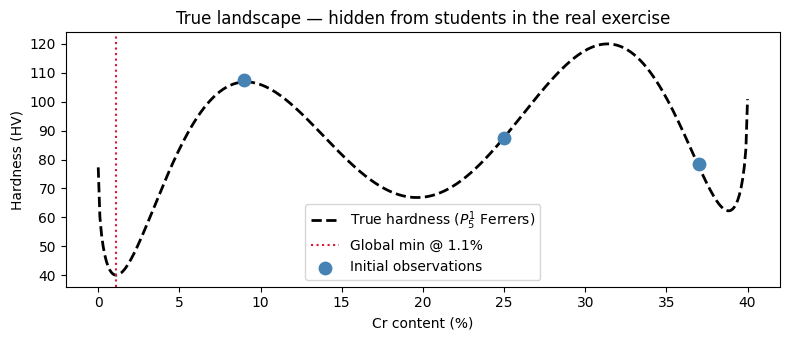

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import lpmv
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

np.random.seed(42)

# ── Ferrers function: Associated Legendre Polynomial P_5^1 ──────────────────
def composition_to_canonical(x):
    """Map composition [0, 40] % Cr  →  canonical domain [-1, 1]"""
    return 2.0 * (x / 40.0) - 1.0

def true_property(x, tilt=1.0):
    """
        x : Cr content in % (0–40).
    """
    x_c = composition_to_canonical(np.asarray(x, dtype=float))
    raw = lpmv(1, 5, x_c) + tilt * x_c

    # Re-normalise over the actual range after tilting
    x_dense = np.linspace(-1, 1, 1000)
    raw_all  = lpmv(1, 5, x_dense) + tilt * x_dense
    raw_min, raw_max = raw_all.min(), raw_all.max()

    return 40.0 + 80.0 * (raw - raw_min) / (raw_max - raw_min)

# Full composition space for plotting
x_space = np.linspace(0, 40, 400)
y_true  = true_property(x_space)

# True global minimum (for reference line in plots)
x_true_min = x_space[np.argmin(y_true)]
y_true_min = y_true.min()

print(f"True global minimum: {y_true_min:.2f} HV at {x_true_min:.2f}% Cr")

# ── Initial observations (same for both strategies) ──────────────────────────
X_init = np.array([9.0, 25.0, 37.0]).reshape(-1, 1)  
y_init = true_property(X_init.ravel()) + np.random.normal(0, 1.5, len(X_init))

# ── Quick look at the true landscape ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(x_space, y_true, 'k--', lw=2, label='True hardness ($P_5^1$ Ferrers)')
ax.axvline(x_true_min, color='crimson', ls=':', lw=1.5, label=f'Global min @ {x_true_min:.1f}%')
ax.scatter(X_init, y_init, s=80, zorder=5, color='steelblue', label='Initial observations')
ax.set_xlabel('Cr content (%)')
ax.set_ylabel('Hardness (HV)')
ax.set_title('True landscape — hidden from students in the real exercise')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Helper functions for Bayesian Optimization on 1D composition space

def fit_gp(X, y):
    """
    Fit a Gaussian Process with a tuned (optimized) kernel.
    We use ConstantKernel * RBF and let sklearn optimize hyperparameters via MLE.
    """
    # Reasonable starting guess + wide bounds so the optimizer can adapt
    kernel = C(1.0, (1e-2, 1e3)) * RBF(length_scale=5.0, length_scale_bounds=(1e-1, 1e2))
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1.5**2,            # observation noise variance (matches how y_init was generated)
        normalize_y=True,
        n_restarts_optimizer=12,
        random_state=42
    )
    gp.fit(X, y)
    return gp

def expected_improvement_min(mu, sigma, f_best, xi=0.0):
    """
    Expected Improvement for *minimization*.
    mu, sigma: predictive mean and std at candidate points (arrays)
    f_best: best observed objective so far (scalar)
    xi: exploration parameter (0 = standard EI)
    """
    sigma = np.maximum(sigma, 1e-12)
    improvement = (f_best - mu) - xi
    z = improvement / sigma
    return improvement * norm.cdf(z) + sigma * norm.pdf(z)

def propose_next_point(strategy, gp, x_grid, y_obs_best):
    """
    Return x_next and acquisition values on x_grid for the given strategy.
    strategy: "EI" (expected improvement) or "MU" (maximum uncertainty)
    """
    mu, sigma = gp.predict(x_grid.reshape(-1, 1), return_std=True)

    if strategy == "EI":
        acq = expected_improvement_min(mu, sigma, f_best=y_obs_best, xi=0.0)
    elif strategy == "MU":
        acq = sigma
    else:
        raise ValueError("strategy must be 'EI' or 'MU'")

    x_next = x_grid[np.argmax(acq)]
    return float(x_next), acq, mu, sigma

def run_bo(strategy, X0, y0, x_grid, max_iter=8, ei_stop=0.10, mu_stop=1.0):
    """
    Run Bayesian optimization / active learning loop and collect per-iteration artifacts.

    Stopping criteria (no peeking at the true minimum):
      - EI: stop if max(EI) < ei_stop (in HV units), or if max_iter reached
      - MU: stop if max(std) < mu_stop (in HV units), or if max_iter reached
    """
    X = X0.copy().reshape(-1, 1)
    y = y0.copy().astype(float)

    iters = []
    predicted_min = []

    for t in range(max_iter):
        gp = fit_gp(X, y)

        # propose next
        y_best = float(np.min(y))
        x_next, acq, mu_grid, sigma_grid = propose_next_point(strategy, gp, x_grid, y_best)

        # predicted global minimum from surrogate (argmin of mean prediction on grid)
        x_pred_min = float(x_grid[np.argmin(mu_grid)])
        y_pred_min = float(np.min(mu_grid))
        predicted_min.append((x_pred_min, y_pred_min))

        # stopping checks based on acquisition landscape
        if strategy == "EI" and float(np.max(acq)) < ei_stop:
            iters.append(dict(gp=gp, X=X.copy(), y=y.copy(), x_next=None, acq=acq, mu=mu_grid, sigma=sigma_grid))
            break
        if strategy == "MU" and float(np.max(sigma_grid)) < mu_stop:
            iters.append(dict(gp=gp, X=X.copy(), y=y.copy(), x_next=None, acq=acq, mu=mu_grid, sigma=sigma_grid))
            break

        # evaluate expensive experiment (here: oracle true_property + measurement noise)
        y_next = float(true_property([x_next])[0] + np.random.normal(0, 1.5, 1)[0])

        # append new observation
        X = np.vstack([X, [[x_next]]])
        y = np.append(y, y_next)

        iters.append(dict(gp=gp, X=X.copy(), y=y.copy(), x_next=x_next, acq=acq, mu=mu_grid, sigma=sigma_grid))

    return iters, predicted_min

def plot_iterations(strategy, iters, x_grid, y_true_curve):
    """
    One figure per strategy, with all iterations as side-by-side subplots.
    Left y-axis: true curve (dashed), GP mean, ±2σ band, observed points
    Right y-axis: acquisition
    """
    n = len(iters)
    fig = plt.figure(figsize=(4.4*n, 3.8))
    gs = gridspec.GridSpec(1, n, wspace=0.45)

    for i, rec in enumerate(iters):
        ax = fig.add_subplot(gs[0, i])
        ax2 = ax.twinx()

        mu = rec["mu"]
        sigma = rec["sigma"]
        acq = rec["acq"]
        X = rec["X"].ravel()
        y = rec["y"].ravel()
        x_next = rec["x_next"]

        # left axis: landscape + GP
        ax.plot(x_grid, y_true_curve, "k--", lw=1.8, label="True (hidden in real)")
        ax.plot(x_grid, mu, lw=2.0, label="GP mean")
        ax.fill_between(x_grid, mu - 2*sigma, mu + 2*sigma, alpha=0.20, label="±2σ")
        ax.scatter(X, y, s=45, zorder=5, label="Obs.")

        if x_next is not None:
            ax.axvline(x_next, ls=":", lw=2.0, label="Next query")

        ax.set_xlabel("Cr content (%)")
        if i == 0:
            ax.set_ylabel("Hardness (HV)")
        ax.set_title(f"{strategy} — iter {i+1}\n{rec['gp'].kernel_}")

        # right axis: acquisition
        ax2.plot(x_grid, acq, lw=1.8)
        if i == n-1:
            ax2.set_ylabel("Acquisition")
        else:
            ax2.set_yticklabels([])

        # make legends readable (only on first subplot)
        if i == 0:
            ax.legend(loc="upper left", fontsize=8)

    plt.suptitle(f"{strategy} strategy: GP + acquisition over iterations", y=1.05, fontsize=12)
    plt.tight_layout()
    plt.show()

C:\Users\Ethan Z\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Ethan Z\AppData\Local\Temp\ipykernel_21336\3531279145.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


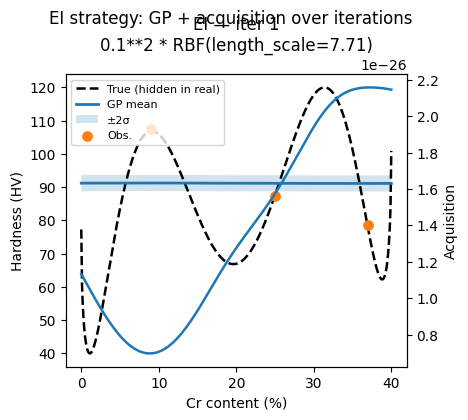

,x_pred_min_%Cr,y_pred_min_HV
1,35.9,91.11765


In [8]:
# Q1

x_grid = np.linspace(0, 40, 401)

ei_iters, ei_pred_min = run_bo(
    strategy="EI",
    X0=X_init,
    y0=y_init,
    x_grid=x_grid,
    max_iter=8,
    ei_stop=0.10   # stop when expected improvement becomes very small
)

plot_iterations("EI", ei_iters, x_grid, y_true_curve=true_property(x_grid))

# Learning trace (surrogate predicted minimum each iteration)
ei_trace = pd.DataFrame(ei_pred_min, columns=["x_pred_min_%Cr", "y_pred_min_HV"])
ei_trace.index = np.arange(1, len(ei_trace)+1)
ei_trace

C:\Users\Ethan Z\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Ethan Z\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Ethan Z\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceW

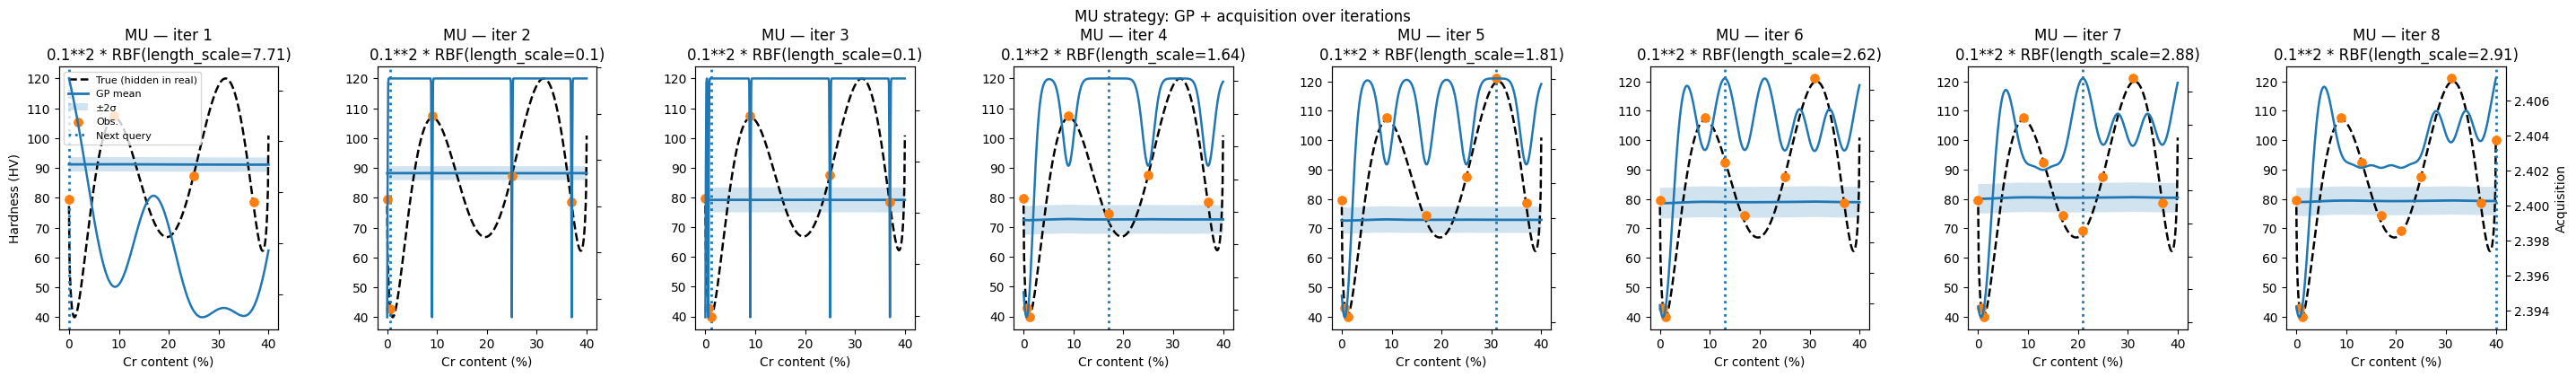

,x_pred_min_%Cr,y_pred_min_HV
1,35.9,91.117650
2,37.0,88.233460
3,0.6,79.016492
4,1.0,72.357364
5,1.0,72.620816
6,0.9,78.557823
7,0.9,80.055550
8,0.9,78.947099


In [9]:
# Q2

x_grid = np.linspace(0, 40, 401)

mu_iters, mu_pred_min = run_bo(
    strategy="MU",
    X0=X_init,
    y0=y_init,
    x_grid=x_grid,
    max_iter=8,
    mu_stop=1.0    # stop when the GP is confident everywhere (std below ~1 HV)
)

plot_iterations("MU", mu_iters, x_grid, y_true_curve=true_property(x_grid))

# Learning trace (surrogate predicted minimum each iteration)
mu_trace = pd.DataFrame(mu_pred_min, columns=["x_pred_min_%Cr", "y_pred_min_HV"])
mu_trace.index = np.arange(1, len(mu_trace)+1)
mu_trace

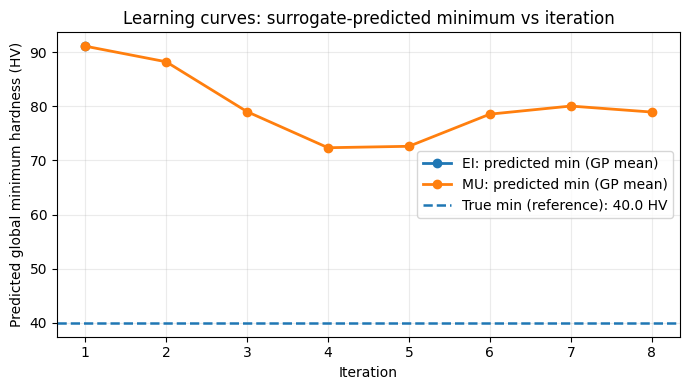

In [10]:
# Q3

# Align lengths for plotting
ei_y = np.array([v[1] for v in ei_pred_min])
mu_y = np.array([v[1] for v in mu_pred_min])

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(ei_y)+1), ei_y, marker="o", lw=2, label="EI: predicted min (GP mean)")
plt.plot(np.arange(1, len(mu_y)+1), mu_y, marker="o", lw=2, label="MU: predicted min (GP mean)")

# Reference (known in this notebook, unknown in a real experiment)
plt.axhline(y_true_min, ls="--", lw=1.8, label=f"True min (reference): {y_true_min:.1f} HV")

plt.xlabel("Iteration")
plt.ylabel("Predicted global minimum hardness (HV)")
plt.title("Learning curves: surrogate-predicted minimum vs iteration")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Submission Instructions - UPDATED

1. Each question must use **one cell**, with all corresponding outputs displayed directly below it.
2. Before submission, make sure **all outputs are visible** (re-run your code one last time). Submit the notebook as a `.ipynb` file on Quercus. 
3. Grading is based on completion. Completion means that **all questions have visible outputs** and all outputs result from your **own** prompts.
4. Completeness Requirement: Every iteration must appear as a visible subplot. A flat prediction or uncertainty band across the majority of your plots for either strategy indicates a poorly tuned kernel and will be treated as an incomplete submission.